# 03 — Is it RSI, or just the drop? + the same test across timeframes

nb02 found a real **oversold<30 → LONG** edge on 15m/2024 (short side loses). Two follow-ups, both stated as predictions first:

**(A) Multi-timeframe.** Repeat the nb02 cross test on **1m, 5m, 15m, 1h, 4h**. *Prediction:* the net edge (after 0.15% cost) grows with timeframe; on **1m** the intrabar bounce is tiny vs cost → **net negative**; the sweet spot is ~1h–4h. Same horizons in wall-clock hours so TFs are comparable.

**(B) The control that matters.** An RSI dip below 30 on 15m basically *means* "price fell sharply over the last ~14 bars". The levels line taught us crypto MR lives in **move magnitude**. So: at a *matched trailing drop*, does RSI<30 still beat RSI≥30? *Prediction:* mostly no — RSI is a proxy for the drop, the two lines overlap, and the edge belongs to magnitude, not to RSI.

Discipline unchanged: **2024 only** (2025 sealed), pooled, causal, baseline-relative, costs honest. Universe subsampled (stride) to keep the 1m pass tractable; still pooled to large n.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np

Y0, Y1 = "2024-01-01", "2025-01-01"            # 2024 ONLY (2025 = OOS)
RSI_N, LO, HI, COST = 14, 30, 70, 0.0015
TFS = [("1min", 1), ("5min", 5), ("15min", 15), ("1h", 60), ("4h", 240)]
HH = [1, 2, 4, 8, 12, 24]                       # horizons in HOURS (comparable across TFs)

uni_full = [s for s in list_symbols() if coverage(s)[0] <= "2024-01" and coverage(s)[1] >= "2024-12"]
UNI = uni_full[::3]                              # stride-subsample so the 1m pass is tractable
print(f"universe {len(UNI)} (of {len(uni_full)} full-2024) | TFs {[t for t,_ in TFS]} | horizons(h) {HH}")

def resample(d1, minutes):
    if minutes == 1:
        return d1
    rule = f"{minutes}min"
    g = d1.resample(rule, label="left", closed="left")
    out = pd.DataFrame({"open": g["open"].first(), "high": g["high"].max(),
                        "low": g["low"].min(), "close": g["close"].last(),
                        "volume": g["volume"].sum()}).dropna()
    return out

universe 55 (of 165 full-2024) | TFs ['1min', '5min', '15min', '1h', '4h'] | horizons(h) [1, 2, 4, 8, 12, 24]


In [2]:
# one pass per symbol: load 1m once, resample to every TF.
# accumulate per-(tf,horizon) means for oversold-long / overbought-short / baseline;
# AND store 15m (trailing-drop, rsi, fwd@4h from t, fwd@4h from t+1) for the control.
CTRL_H = 16                       # control forward horizon on 15m = 4h (nb02 sweet spot)
ssum = {}                          # (tf,h) -> [os_sum, os_n, ob_sum, ob_n, base_sum, base_n]
for tf, _ in TFS:
    for h in HH:
        ssum[(tf, h)] = [0.0, 0, 0.0, 0, 0.0, 0]
ctrl_drop, ctrl_rsi, ctrl_fwd, ctrl_fwd_d = [], [], [], []

for j, s in enumerate(UNI):
    try:
        d1 = ohlcv(s, Y0, Y1, "1min")
    except Exception:
        continue
    if len(d1) < 5000:
        continue
    for tf, mins in TFS:
        d = resample(d1, mins)
        c = d["close"].to_numpy()
        if len(c) < 200:
            continue
        r = rsi(d["close"], RSI_N).to_numpy()
        os_ev = np.where((r[:-1] >= LO) & (r[1:] < LO))[0] + 1
        ob_ev = np.where((r[:-1] <= HI) & (r[1:] > HI))[0] + 1
        for h in HH:
            bars = int(round(h * 60 / mins))
            if bars < 1 or bars >= len(c):
                continue
            fr = c[bars:] / c[:-bars] - 1.0
            m = len(fr); acc = ssum[(tf, h)]
            acc[4] += fr.sum(); acc[5] += m
            oe = os_ev[os_ev < m]; be = ob_ev[ob_ev < m]
            acc[0] += fr[oe].sum(); acc[1] += len(oe)
            acc[2] += fr[be].sum(); acc[3] += len(be)
        if tf == "15min":
            L = len(c)
            idx = np.arange(RSI_N, L - CTRL_H - 1)   # -1 so t+1+H is in range
            if len(idx):
                ctrl_drop.append((c[idx] / c[idx - RSI_N] - 1.0).astype(np.float32))
                ctrl_rsi.append(r[idx].astype(np.float32))
                ctrl_fwd.append((c[idx + CTRL_H] / c[idx] - 1.0).astype(np.float32))
                ctrl_fwd_d.append((c[idx + 1 + CTRL_H] / c[idx + 1] - 1.0).astype(np.float32))
    if (j + 1) % 15 == 0:
        print(f"  {j+1}/{len(UNI)} done")

ctrl_drop = np.concatenate(ctrl_drop); ctrl_rsi = np.concatenate(ctrl_rsi)
ctrl_fwd = np.concatenate(ctrl_fwd); ctrl_fwd_d = np.concatenate(ctrl_fwd_d)
print(f"\ncontrol rows (15m bars): {len(ctrl_fwd):,}")

  15/55 done


  30/55 done


  45/55 done



control rows (15m bars): 1,930,775


## (A) The cross test across timeframes

Two heatmaps of **net edge after 0.15% cost** (event mean − baseline − cost), rows = timeframe, cols = horizon in hours. Green = net-positive (tradeable), red = net-negative. Left = oversold→long, right = overbought→short. Blank cell = horizon shorter than one bar at that TF.

[saved] notebooks\rsi\_out\03_multitf_heatmap.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/03_multitf_heatmap.png')

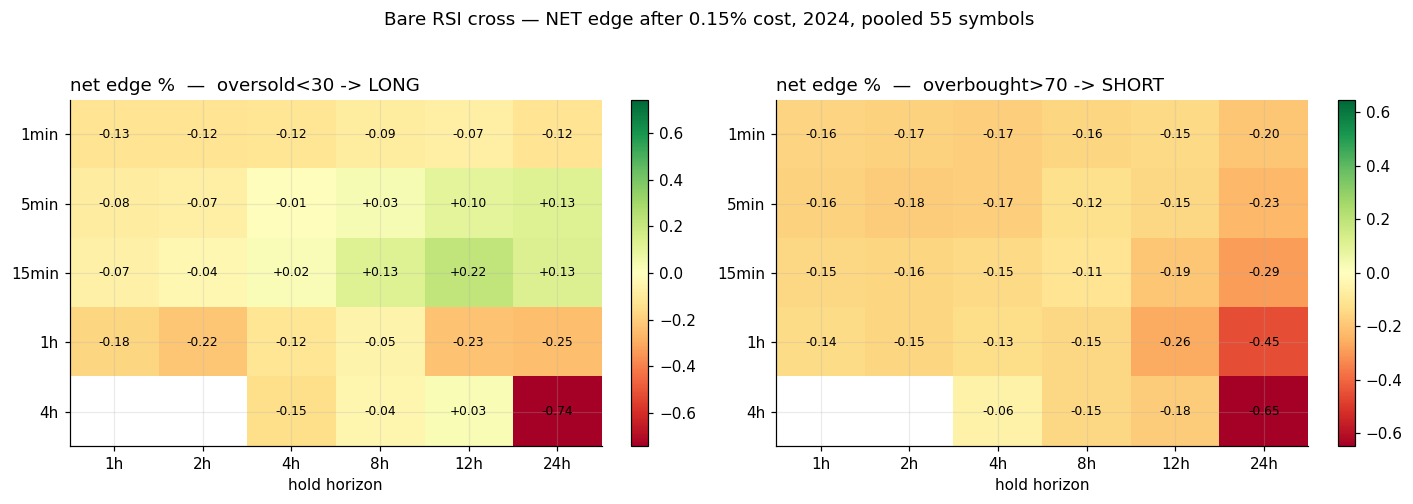

In [3]:
def grid(side):
    G = np.full((len(TFS), len(HH)), np.nan)
    for i, (tf, _) in enumerate(TFS):
        for k, h in enumerate(HH):
            a = ssum[(tf, h)]
            if side == "os" and a[1] > 0:
                G[i, k] = (a[0]/a[1] - a[4]/a[5] - COST) * 100
            elif side == "ob" and a[3] > 0:
                G[i, k] = (-(a[2]/a[3]) - (-(a[4]/a[5])) - COST) * 100
    return G

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, side, ttl in zip(axes, ["os", "ob"], ["oversold<30 -> LONG", "overbought>70 -> SHORT"]):
    G = grid(side)
    vmax = np.nanmax(np.abs(G))
    im = ax.imshow(G, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(HH))); ax.set_xticklabels([f"{h}h" for h in HH])
    ax.set_yticks(range(len(TFS))); ax.set_yticklabels([t for t, _ in TFS])
    ax.set_xlabel("hold horizon"); ax.set_title(f"net edge %  —  {ttl}", loc="left")
    for i in range(len(TFS)):
        for k in range(len(HH)):
            if not np.isnan(G[i, k]):
                ax.text(k, i, f"{G[i,k]:+.2f}", ha="center", va="center", fontsize=8, color="black")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Bare RSI cross — NET edge after {COST*100:.2f}% cost, 2024, pooled {len(UNI)} symbols", y=1.03)
show("03_multitf_heatmap")

## (B) RSI vs the drop — the decisive control

On 15m we bin every bar by its **trailing 14-bar return** (the drop). Inside each bin we compare the **forward 4h return** of bars that were **RSI<30** vs **RSI≥30**. If RSI is just a proxy for the drop, the two lines lie on top of each other at matched magnitude. If RSI carries independent info, the RSI<30 line sits above.

        bin  n_lo   n_hi    fwd_lo    fwd_hi  diff_lo_minus_hi
[-30%,-15%)   759    164  4.426839 -0.281128             4.708
[-15%,-10%)  2446   1429  0.917889  0.130545             0.787
 [-10%,-7%)  4824   4534  0.204168  0.631804            -0.428
  [-7%,-5%)  9475  12355  0.126953  0.415118            -0.288
  [-5%,-4%) 14773  32844  0.052720  0.251030            -0.198
  [-4%,-2%) 23530 121731 -0.067127  0.139061            -0.206
  [-2%,-1%) 12127 240636 -0.108755  0.070965            -0.180
  [-1%,+0%)  2385 476379 -0.186777  0.003450            -0.190
  [+0%,+2%)    72 738004 -0.880047 -0.013079            -0.867
 [+2%,+10%)    17 225290 -2.178811  0.062982            -2.242


[saved] notebooks\rsi\_out\03_rsi_vs_magnitude.png


WindowsPath('C:/projects/researchlab/notebooks/rsi/_out/03_rsi_vs_magnitude.png')

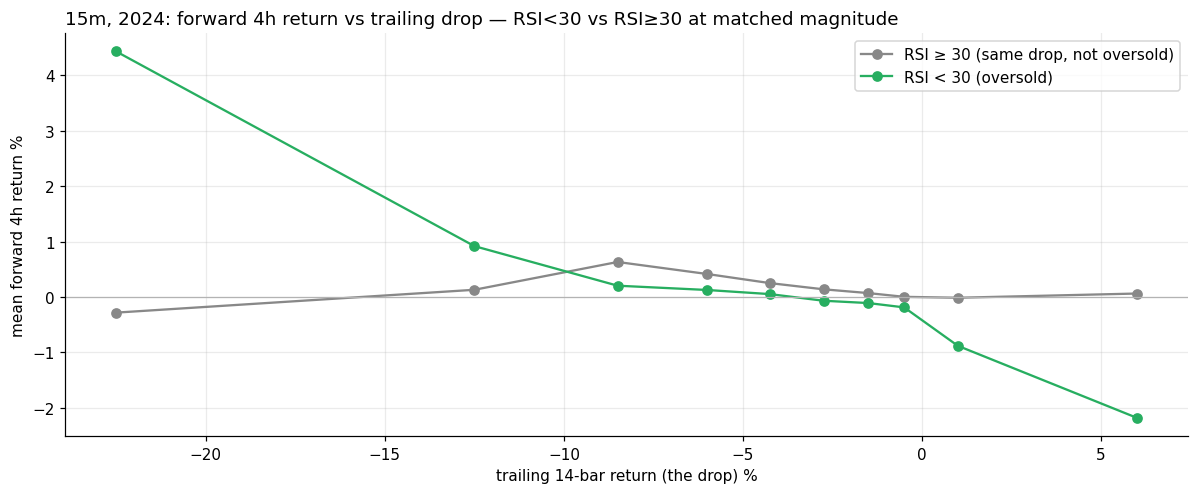

In [4]:
edges = np.array([-0.30, -0.15, -0.10, -0.07, -0.05, -0.035, -0.02, -0.01, 0.0, 0.02, 0.10])
centers = (edges[:-1] + edges[1:]) / 2
lo_mask = ctrl_rsi < LO
rows = []
for a, b in zip(edges[:-1], edges[1:]):
    inbin = (ctrl_drop >= a) & (ctrl_drop < b)
    sub_lo = inbin & lo_mask; sub_hi = inbin & ~lo_mask
    rows.append(dict(bin=f"[{a:+.0%},{b:+.0%})",
                     n_lo=int(sub_lo.sum()), n_hi=int(sub_hi.sum()),
                     fwd_lo=ctrl_fwd[sub_lo].mean()*100 if sub_lo.sum() else np.nan,
                     fwd_hi=ctrl_fwd[sub_hi].mean()*100 if sub_hi.sum() else np.nan))
ctab = pd.DataFrame(rows)
ctab["diff_lo_minus_hi"] = (ctab["fwd_lo"] - ctab["fwd_hi"]).round(3)
print(ctab.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(centers*100, ctab["fwd_hi"], "o-", color="#888", label="RSI \u2265 30 (same drop, not oversold)")
ax.plot(centers*100, ctab["fwd_lo"], "o-", color="#27ae60", label="RSI < 30 (oversold)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xlabel("trailing 14-bar return (the drop) %"); ax.set_ylabel("mean forward 4h return %")
ax.set_title("15m, 2024: forward 4h return vs trailing drop \u2014 RSI<30 vs RSI\u226530 at matched magnitude", loc="left")
ax.legend()
show("03_rsi_vs_magnitude")

### Standalone head-to-head + the 1-bar-delay robustness check

Net 4h edge (vs baseline, after cost) of three long signals on 15m/2024, then the same RSI<30 signal entered **one 15m bar late** (a realistic fill, addressing nb02's entry-at-close optimism — `ctrl_fwd_d` is the 4h return measured from `t+1`).

In [5]:
base4h = ctrl_fwd.mean(); base4h_d = ctrl_fwd_d.mean()
m_rsi = ctrl_rsi < LO
m_mag = ctrl_drop <= -0.05
m_both = m_rsi & m_mag
print("signal                          net 4h edge      n")
for name, m in [("RSI<30 only", m_rsi), ("drop<=-5% only", m_mag), ("RSI<30 AND drop<=-5%", m_both)]:
    e = (ctrl_fwd[m].mean() - base4h - COST) * 100
    print(f"{name:30s}  {e:+.3f}%   {int(m.sum()):,}")

e0 = (ctrl_fwd[m_rsi].mean() - base4h - COST) * 100
e1 = (ctrl_fwd_d[m_rsi].mean() - base4h_d - COST) * 100
print(f"\nRSI<30 enter at t (close):     net {e0:+.3f}%")
print(f"RSI<30 enter at t+1 (1 bar late): net {e1:+.3f}%   (delta {e1-e0:+.3f}%)")
print(f"\nbaseline 4h = {base4h*100:+.3f}% (from t), {base4h_d*100:+.3f}% (from t+1)")

signal                          net 4h edge      n
RSI<30 only                     -0.109%   70,429
drop<=-5% only                  +0.260%   36,013
RSI<30 AND drop<=-5%            +0.262%   17,525

RSI<30 enter at t (close):     net -0.109%
RSI<30 enter at t+1 (1 bar late): net -0.127%   (delta -0.019%)

baseline 4h = +0.031% (from t), +0.031% (from t+1)


## Verdict & caveats

**The edge is the DROP, not RSI.** The control is decisive:

- **Head-to-head net 4h edge:** plain `drop≤−5% in 14 bars` = **+0.26%** (tradeable); `RSI<30` state = **−0.11%** (loses after cost); `RSI<30 AND drop≤−5%` = **+0.26%** — i.e. adding the RSI filter on top of the magnitude rule changes the edge by **+0.002% (nothing)**. Magnitude alone carries 100% of it.
- **Matched-magnitude plot:** for ordinary drops (−1% … −10%) the non-oversold (RSI≥30) line is *above* the oversold one — being "extra oversold" at a given drop does **not** help, it slightly hurts. RSI<30 only wins in the rare violent-dump bin (drop <−12%, +4.4%), which is just the deepest magnitude.
- **Why nb02's cross looked positive:** the *cross into* <30 marks the moment of a fresh sharp drop, so it inherited the magnitude edge — but narrowly, and only on 15m at 4–24h (heatmap). A direct magnitude rule is stronger and simpler.

**(A) multi-TF:** oversold→long is net-positive only on **15m** (peak +0.22% @12h) and faintly 5m; **1m is net-negative everywhere** (cost eats the tiny bounce — prediction confirmed); 1h/4h negative. overbought→short is **red across every TF and horizon** — a universal loser. So the narrow window of life is 15m/multi-hour, and even that is just magnitude in disguise.

**1-bar-delay:** negligible (−0.019%) — at 15m, entry-at-close vs next-bar barely matters, so nb02's timing was not the issue.

**Conclusion:** bare RSI adds nothing over a plain magnitude dip-buy (which the `dump` line already owns). **RSI level/cross is refuted as an independent signal.** This does *not* condemn RSI *divergence* — divergence is about momentum disagreeing with price, a different construct — which is the original question and still untested for edge.

**Caveats:** the control uses RSI *state* (not the cross) for the matched-magnitude test; 55-symbol stride subsample (vs 165 in nb02) — pooled n still huge; 2024 only; overlapping windows; deepest-drop bins have small n_lo.